**Final Portfolio**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder #encode catagorical values
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso




In [ ]:
data = pd.read_csv("/content/accepted_2007_to_2018Q4.csv", nrows=50000)
df = pd.DataFrame(data)

Data Descriptions

In [ ]:
print(df.info())
print(df.describe())
print(df.size)
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Columns: 151 entries, id to settlement_term
dtypes: float64(115), int64(1), object(35)
memory usage: 1.6+ MB
None
                 id  member_id     loan_amnt   funded_amnt  funded_amnt_inv  \
count  1.397000e+03        0.0   1397.000000   1397.000000      1397.000000   
mean   6.831285e+07        NaN  15376.825340  15376.825340     15376.825340   
std    1.856157e+06        NaN   8722.759648   8722.759648      8722.759648   
min    6.995750e+05        NaN   1000.000000   1000.000000      1000.000000   
25%    6.837701e+07        NaN   8400.000000   8400.000000      8400.000000   
50%    6.846628e+07        NaN  14225.000000  14225.000000     14225.000000   
75%    6.854644e+07        NaN  21000.000000  21000.000000     21000.000000   
max    6.861706e+07        NaN  35000.000000  35000.000000     35000.000000   

          int_rate  installment     annual_inc  desc          dti  ...  \
count  1397.000000  1397.0

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [ ]:


#deleating rows that values are missing more then 40%
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.4].index

df = df.drop(columns=cols_to_drop)




In [ ]:

df.isnull().sum().sort_values(ascending=False)


,0
il_util,161
mths_since_recent_inq,156
num_tl_120dpd_2m,99
emp_title,56
emp_length,55
...,...
tot_coll_amt,0
open_acc_6m,0
open_act_il,0
open_il_12m,0


In [ ]:

missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

,0
il_util,0.115247
mths_since_recent_inq,0.111668
num_tl_120dpd_2m,0.070866
emp_title,0.040086
emp_length,0.039370
title,0.028633
mo_sin_old_il_acct,0.018611
mths_since_rcnt_il,0.017895
bc_util,0.012169
bc_open_to_buy,0.011453


In [ ]:
# These columns often come as strings and must be converted:
# term (e.g., “36 months”)
df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# int_rate & revol_util (e.g., “13.56%”)
for c in ['int_rate', 'revol_util']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.replace('%','', regex=False)
        df[c] = pd.to_numeric(df[c], errors='coerce')

# emp_length (e.g., “10+ years”, “< 1 year”)
def clean_emp_length(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    if '<' in x:
        return 0
    if '10+' in x:
        return 10
    num = ''.join([ch for ch in x if ch.isdigit()])
    return float(num) if num else np.nan

df['emp_length'] = df['emp_length'].apply(clean_emp_length)




In [ ]:
target = "loan_amnt"

leak_cols = [
    'funded_amnt','funded_amnt_inv','out_prncp','out_prncp_inv',
    'total_pymnt','total_pymnt_inv','total_rec_prncp','total_rec_int',
    'total_rec_late_fee','recoveries','collection_recovery_fee',
    'last_pymnt_d','last_pymnt_amnt','next_pymnt_d',
    'last_credit_pull_d','last_fico_range_high','last_fico_range_low',
    'loan_status','url','desc','installment' # added due to strong deterministic relationship with target
]

# hardship/settlement groups (drop if present)
leak_cols += [c for c in df.columns if c.startswith('hardship_')]
leak_cols += [c for c in df.columns if c.startswith('debt_settlement')]
leak_cols += [c for c in df.columns if c.startswith('settlement_')]

cols_to_drop = [c for c in leak_cols if c in df.columns]
df_model = df.drop(columns=cols_to_drop)

df_model = df_model.drop_duplicates()

X = df_model.drop(columns=[target])
y = df_model[target]


In [ ]:
# Train-test split (before imputation to avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Separate numeric and categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns


In [ ]:


# Numeric preprocessing: median impute + scale
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing: mode impute + one-hot encode
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


In [ ]:
# Apply preprocessing (fit on train only)
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)


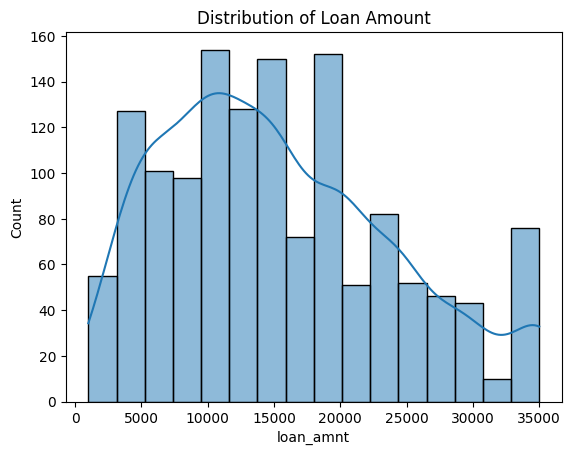

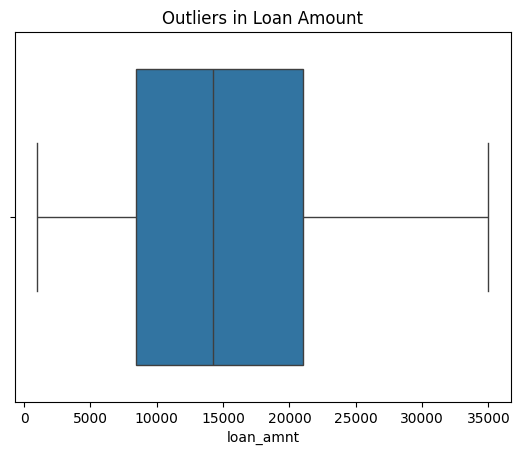

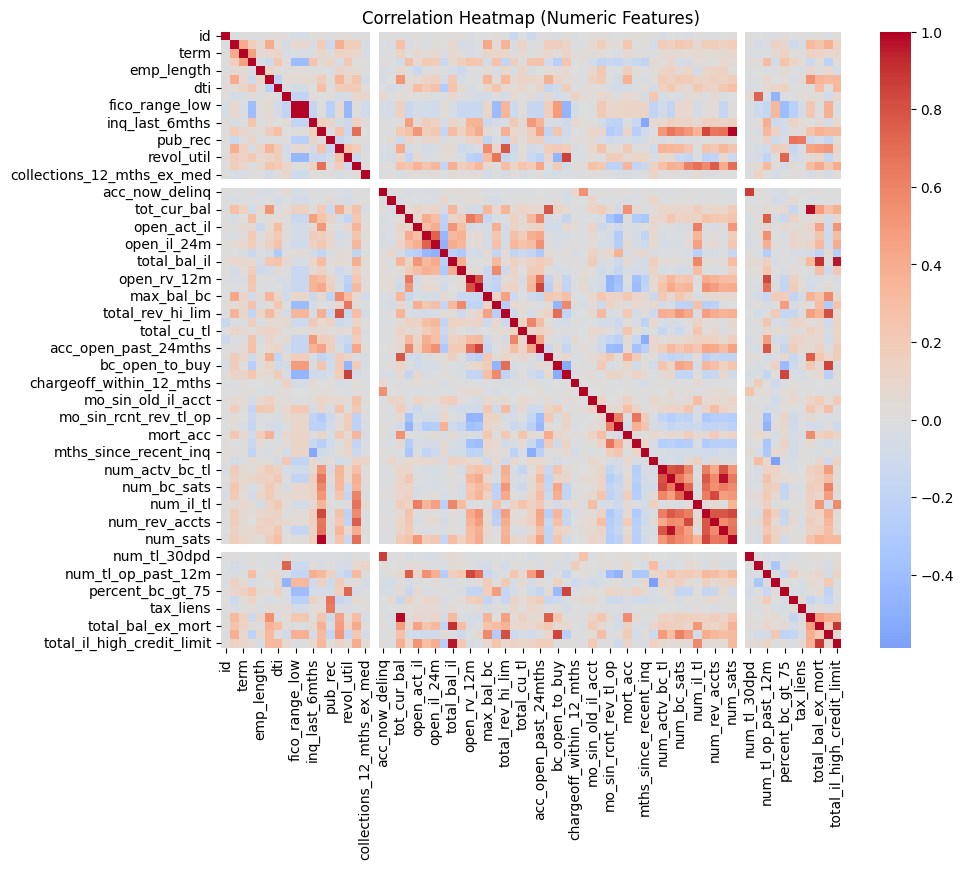

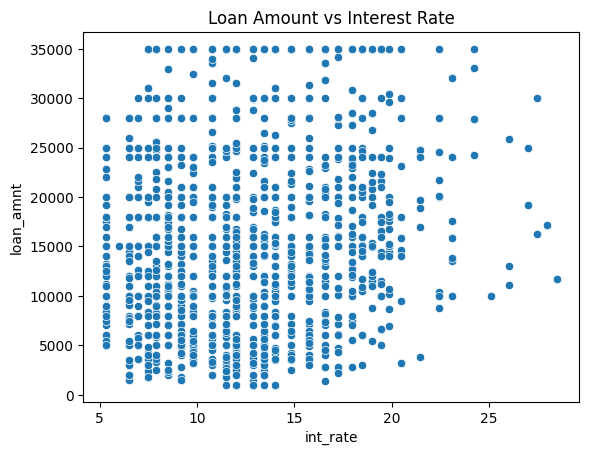

In [ ]:
# visualize the data
plt.figure()
sns.histplot(df_model[target], kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

plt.figure()
sns.boxplot(x=df_model[target])
plt.title("Outliers in Loan Amount")
plt.show()

# Numeric correlations
num_df = df_model.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Relationship example
plt.figure()
sns.scatterplot(x=df_model['int_rate'], y=df_model[target])
plt.title("Loan Amount vs Interest Rate")
plt.show()

“Highly correlated leakage variables were removed to prevent biased predictions.”

In [ ]:
print(X_train_pre.shape, X_test_pre.shape)

(1117, 1814) (280, 1814)


In [ ]:
# Neural Network (MLP) for Regression
nn_model = Pipeline(steps=[
    ("prep", preprocessor),# preprocessing: imputation, scaling, encoding
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),  # two hidden layers
        activation="relu",            # activation function
        solver="adam",                # optimizer
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
        early_stopping=True
    ))
])



In [ ]:

# Train the neural network
nn_model.fit(X_train, y_train)

# Predictions
y_train_pred = nn_model.predict(X_train)
y_test_pred  = nn_model.predict(X_test)

# Evaluation
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Neural Network Performance")
print("Train -> MSE:", mse_train, "RMSE:", rmse_train, "R2:", r2_train)
print("Test  -> MSE:", mse_test,  "RMSE:", rmse_test,  "R2:", r2_test)

Neural Network Performance
Train -> MSE: 37682762.513930604 RMSE: 6138.62871608396 R2: 0.5029023097275276
Test  -> MSE: 46615281.32039085 RMSE: 6827.538452501813 R2: 0.39363424310348893


**Model 1: Linear Regression**

In [ ]:

lin_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

# Train
lin_model.fit(X_train, y_train)

# Predict
lin_train_pred = lin_model.predict(X_train)
lin_test_pred  = lin_model.predict(X_test)


In [ ]:

# Metrics
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{label}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.3f}")

evaluate(y_train, lin_train_pred, "Linear Regression – Train")
evaluate(y_test,  lin_test_pred,  "Linear Regression – Test")



Linear Regression – Train
MAE : 3.89
MSE : 33.72
RMSE: 5.81
R²  : 1.000

Linear Regression – Test
MAE : 7558.87
MSE : 93902523.35
RMSE: 9690.33
R²  : -0.221


**Model 2: KNN Regressor**

In [ ]:

knn_model = Pipeline([
    ("prep", preprocessor),   # scaling is VERY important for KNN
    ("model", KNeighborsRegressor(
        n_neighbors=5,
        weights="distance"
    ))
])

# Train
knn_model.fit(X_train, y_train)

# Predict
knn_train_pred = knn_model.predict(X_train)
knn_test_pred  = knn_model.predict(X_test)

# Metrics
evaluate(y_train, knn_train_pred, "KNN Regression – Train")
evaluate(y_test,  knn_test_pred,  "KNN Regression – Test")



KNN Regression – Train
MAE : 0.00
MSE : 0.00
RMSE: 0.00
R²  : 1.000

KNN Regression – Test
MAE : 6350.76
MSE : 62281047.94
RMSE: 7891.83
R²  : 0.190


In [ ]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


**Ridge Regression Pipeline**

In [ ]:
ridge_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])
# Ridge Hyperparameter Grid
ridge_param_grid = {
    "model__alpha": np.logspace(-3, 3, 13)  # 0.001 → 1000
}


**Ridge GridSearch**

In [ ]:
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=2
)

ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['id', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti',
       'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6m...
       'application_type', 'disbursement_method'],
      dtype='object'))])),
                                       ('model', Ridge())]),
             n_jobs=2,
             param_grid={'model__alpha': array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01, 3.16227766e+01, 1.00000000e+02, 3.16227766e+02,
       1.00000000e+03])},
             scoring='neg_root_mean_squared_error')

In [ ]:

print("Ridge Best Params:", ridge_grid.best_params_)
print("Ridge Best CV RMSE:", -ridge_grid.best_score_)

Ridge Best Params: {'model__alpha': np.float64(100.0)}
Ridge Best CV RMSE: 6845.643074857214


**Ridge Test Evaluation**

In [ ]:
ridge_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_

ridge_pred = ridge_best.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Test RMSE:", ridge_rmse)
print("Ridge Test R²:", ridge_r2)

Ridge Test RMSE: 6761.607433713691
Ridge Test R²: 0.40528859979006937


**KNN Regression Pipeline**

In [ ]:
knn_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsRegressor())
])


**KNN Hyperparameter Grid**

In [ ]:
knn_param_grid = {
    "model__n_neighbors": [5, 11, 21, 31],
    "model__weights": ["uniform", "distance"]
}

**RandomizedSearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

knn_param_dist = {
    "model__n_neighbors": list(range(3, 41, 2)),
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_search = RandomizedSearchCV(
    estimator=knn_pipe,
    param_distributions=knn_param_dist,
    n_iter=20,          # ← KEY: limit trials
    cv=3,               # ← reduce CV
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

knn_search.fit(X_train, y_train)

print("KNN Best Params:", knn_search.best_params_)
print("KNN Best CV RMSE:", -knn_search.best_score_)


KNN Best Params: {'model__weights': 'distance', 'model__n_neighbors': 17, 'model__metric': 'manhattan'}
KNN Best CV RMSE: 7180.245296249006


**KNN Test Evaluation**

In [ ]:
# Best model from RandomizedSearchCV
knn_best = knn_search.best_estimator_

# Predictions on test set
knn_pred = knn_best.predict(X_test)

# Evaluation metrics
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Test RMSE:", knn_rmse)
print("KNN Test R²:", knn_r2)


KNN Test RMSE: 7252.917564295664
KNN Test R²: 0.31572316061277284


idge handles multicollinearity using L2 regularization

KNN captures local, non-linear patterns but needs scaling

Pipeline prevents data leakage

GridSearchCV + CV ensures robust hyperparameter tuning

RMSE chosen because it is in the same unit as target variable

In [ ]:

def test_report(best_model, name):
    pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    print(f"\n{name} Test Performance")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.3f}")

test_report(ridge_grid.best_estimator_, "Tuned Ridge")
test_report(knn_search.best_estimator_, "Tuned KNN")



Tuned Ridge Test Performance
MAE : 5392.40
MSE : 45719335.09
RMSE: 6761.61
R²  : 0.405

Tuned KNN Test Performance
MAE : 5914.34
MSE : 52604813.19
RMSE: 7252.92
R²  : 0.316


**Lasso for Feature Selection**

In [ ]:
# Lasso for feature selection
lasso_pipe = Pipeline([
    ("prep", preprocessor),
    ("lasso", Lasso(alpha=0.01, max_iter=5000, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = lasso_pipe.named_steps["prep"].get_feature_names_out()

# Get coefficients
coefficients = lasso_pipe.named_steps["lasso"].coef_

# Select non-zero coefficient features
selected_features = feature_names[coefficients != 0]

print("Number of selected features:", len(selected_features))


Number of selected features: 1370


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 53930949.9980935, tolerance: 8467479.642681291
  model = cd_fast.sparse_enet_coordinate_descent(


**Reduce datasets to selected features**

In [ ]:
# Transform full datasets
X_train_all = preprocessor.fit_transform(X_train)
X_test_all  = preprocessor.transform(X_test)

# Mask for selected features
mask = coefficients != 0

X_train_sel = X_train_all[:, mask]
X_test_sel  = X_test_all[:, mask]


**Train models using selected features**

1.   List item
2.   List item



In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge_sel = Ridge(alpha=1.0, random_state=42)
ridge_sel.fit(X_train_sel, y_train)

ridge_pred = ridge_sel.predict(X_test_sel)

print("Ridge (Selected Features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2:", r2_score(y_test, ridge_pred))


Ridge (Selected Features)
RMSE: 7703.235217988119
R2: 0.22811486651938173


**KNN Regression (with selected features)**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_sel = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn_sel.fit(X_train_sel, y_train)

knn_pred = knn_sel.predict(X_test_sel)

print("\nKNN (Selected Features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))
print("R2:", r2_score(y_test, knn_pred))



KNN (Selected Features)
RMSE: 7883.504144863836
R2: 0.19156527692244918


**Rebuild FINAL models with optimal hyperparameters**

In [ ]:
# Use best alpha from GridSearch (example: alpha=10)
final_ridge = Ridge(alpha=ridge_grid.best_params_["model__alpha"],
                    random_state=42)

final_ridge.fit(X_train_sel, y_train)

ridge_pred = final_ridge.predict(X_test_sel)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)


**Final Model 2: KNN Regression (Tuned + Selected Features)**

In [ ]:

final_knn = KNeighborsRegressor(
    n_neighbors=knn_search.best_params_["model__n_neighbors"],
    weights=knn_search.best_params_["model__weights"]
)

final_knn.fit(X_train_sel, y_train)

knn_pred = final_knn.predict(X_test_sel)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)


**Get CV scores (from Task 4)**

In [ ]:
ridge_cv = -ridge_grid.best_score_   # RMSE
knn_cv   = -knn_search.best_score_


**Create the Final Comparison Table**

In [ ]:

final_results = pd.DataFrame({
    "Model": ["Ridge Regression", "KNN Regression"],
    "Features Used": [
        f"Selected ({X_train_sel.shape[1]})",
        f"Selected ({X_train_sel.shape[1]})"
    ],
    "CV RMSE": [ridge_cv, knn_cv],
    "Test RMSE": [ridge_rmse, knn_rmse],
    "Test R²": [ridge_r2, knn_r2]
})

final_results


,Model,Features Used,CV RMSE,Test RMSE,Test R²
0,Ridge Regression,Selected (1370),6845.643075,6775.277973,0.402881
1,KNN Regression,Selected (1370),7180.245296,7514.739099,0.265428
